# Kadai 2
Bifurcation diagrams — Logistic map and Lorenz system.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

## 1. Bifurcation Diagram — Logistic Map
$$x_{n+1} = a x_n(1-x_n), \quad a \in [0,4]$$

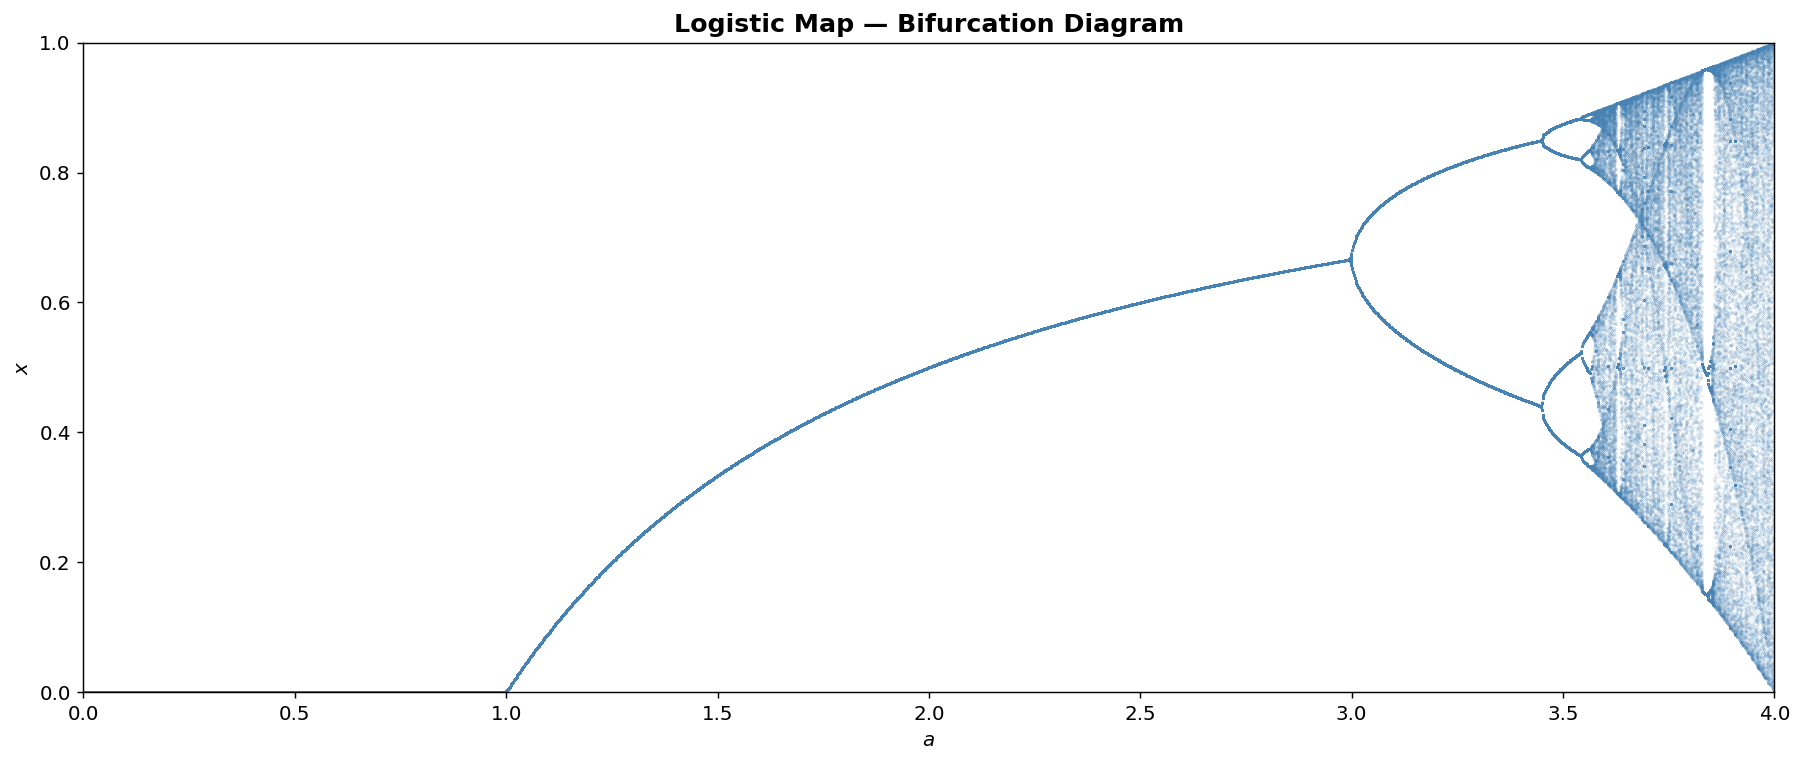

In [2]:
transient = 500
keep = 300
a_values = np.linspace(0, 4, 2000)

a_plot, x_plot = [], []

for a in a_values:
    x = 0.5
    for _ in range(transient):
        x = a * x * (1 - x)
    for _ in range(keep):
        x = a * x * (1 - x)
        a_plot.append(a)
        x_plot.append(x)

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(a_plot, x_plot, s=0.05, c='steelblue', alpha=0.3)
ax.set_title('Logistic Map — Bifurcation Diagram', fontweight='bold', fontsize=14)
ax.set_xlabel('$a$'); ax.set_ylabel('$x$')
ax.set_xlim(0, 4); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 2. Bifurcation Diagram — Lorenz System
$$\dot{x}=\sigma(y-x),\quad \dot{y}=x(r-z)-y,\quad \dot{z}=xy-bz$$
$\sigma=10,\; b=8/3,\; r \in [0,200]$

Poincaré section: $\dot{z}=0$ (i.e. $xy = bz$), with $\dot{z}$ changing sign from $-$ to $+$ (local minima of $z$).

Total Poincare points: 60318


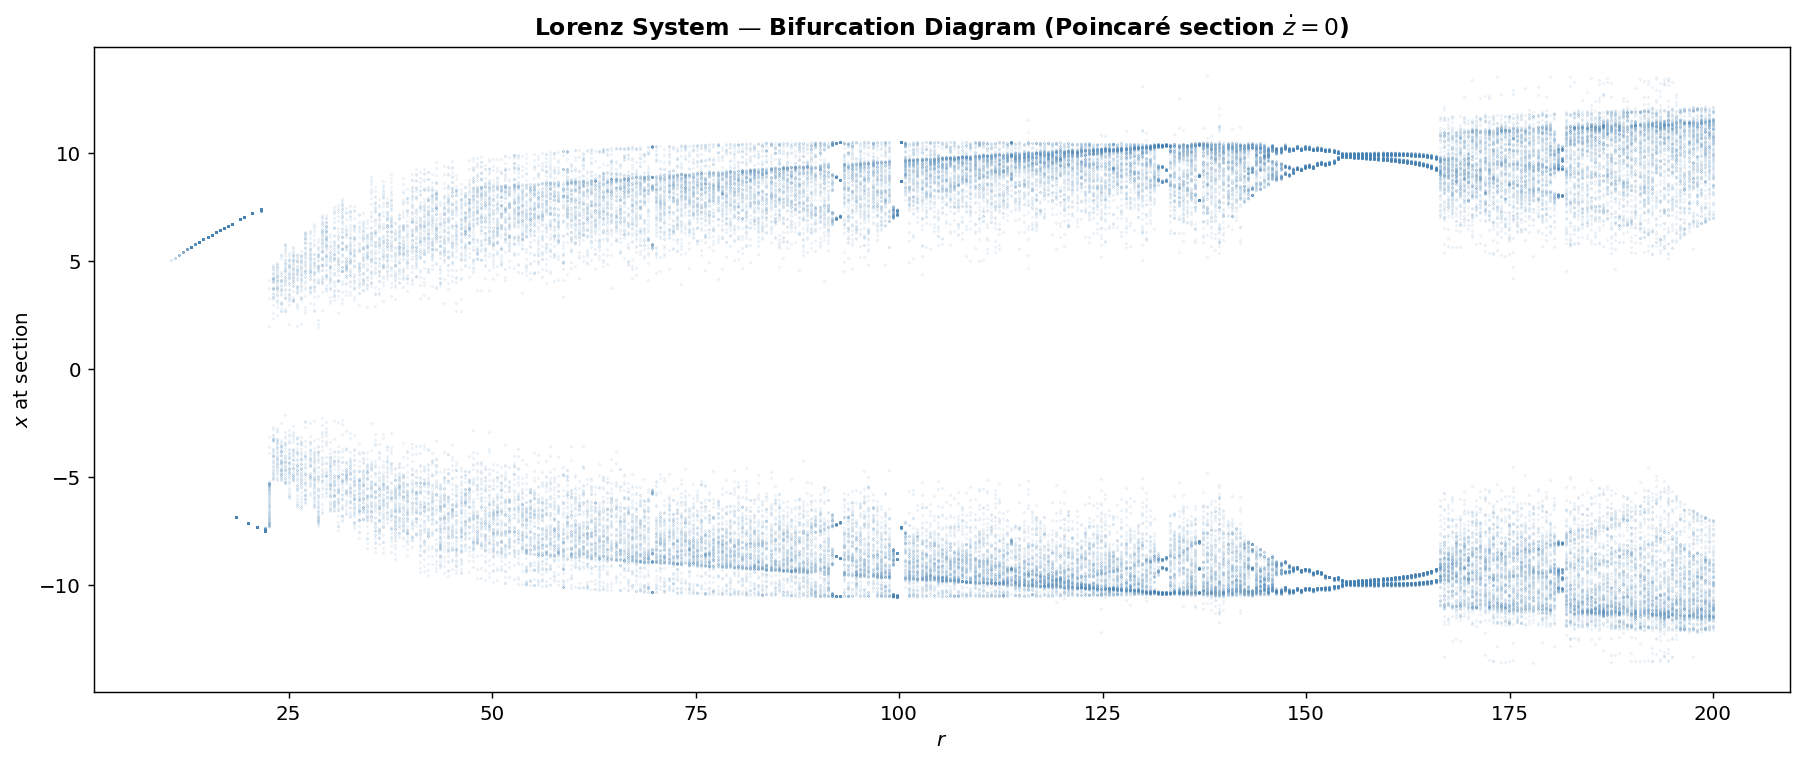

In [4]:
def lorenz_rhs(t, state, sigma, r, b):
    x, y, z = state
    return [sigma*(y - x), x*(r - z) - y, x*y - b*z]

sigma, b = 10.0, 8/3
r_values = np.linspace(0, 200, 400)  # 400 r values

r_plot, x_plot = [], []

for r in r_values:
    try:
        # integrate long enough; drop transient via t_span
        sol = solve_ivp(
            lorenz_rhs, [0, 120], [1.0, 0.0, r - 1 if r > 1 else 0.5],
            args=(sigma, r, b),
            max_step=0.02, dense_output=False,
            events=None
        )
        t_arr = sol.t; xs, ys, zs = sol.y

        # drop first half as transient
        half = len(t_arr) // 2
        xs, ys, zs = xs[half:], ys[half:], zs[half:]

        # Poincare section: zdot = xy - b*z = 0, sign change ->
        zdot = xs*ys - b*zs
        crossings = np.where((zdot[:-1] < 0) & (zdot[1:] >= 0))[0]

        for idx in crossings:
            # linear interpolation for x at crossing
            frac = -zdot[idx] / (zdot[idx+1] - zdot[idx])
            x_cross = xs[idx] + frac * (xs[idx+1] - xs[idx])
            r_plot.append(r)
            x_plot.append(x_cross)
    except Exception:
        pass

print(f"Total Poincare points: {len(r_plot)}")

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(r_plot, x_plot, s=0.05, c='steelblue', alpha=0.3)
ax.set_title('Lorenz System — Bifurcation Diagram (Poincaré section $\\dot{z}=0$)', fontweight='bold', fontsize=13)
ax.set_xlabel('$r$'); ax.set_ylabel('$x$ at section')
plt.tight_layout()
plt.show()